# Rolling cumulative forecast targets

Notebook 04c created one forecast at the opening date and used its target for the whole run. This bridge keeps the same forecast-to-inventory boundary, but repeats the handoff when later demand becomes observable. The result is still one ordinary `(R, S)` policy configuration; only its fitted target is refreshed.

```text
newly observed demand → external forecast refit → cumulative target → fitted policy snapshot → scheduled engine decision
```

Stockcast does not fit forecasting models inside `SimulationEngine`. The engine consumes already fitted policy snapshots, just as it consumes an already prepared demand table and opening inventory state. Forecast fitting, model choice, and cumulative uncertainty remain responsibilities of the external forecasting workflow.

Timing is important. Due receipts precede the decision, and current demand follows it. A snapshot keyed to demand period 4 may use observed demand periods 0 through 3, but must exclude period 4 and all later demand.

In a live application, an outer scheduler would create each snapshot only when its date arrives. This deterministic notebook prepares all snapshots before the engine run so the complete example can execute in one pass. The expanding-history slices below preserve exactly the information that would have been available at each live origin.

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from smooth import ES

from stockcast import InventoryStateDataFrame, OrderUpToPolicy, SimulationEngine
from stockcast.evaluation import (
    InventoryEvaluator, avg_on_hand, demand_period_service_level,
    fill_rate, order_units,
)


In [2]:
# The SKU and opening date identify the one series and its first decision point.
sku = 'tea_250g'
opening_date = pd.Timestamp('2026-02-14')
period_frequency = 'D'
# Orders take two days to arrive, and inventory is reviewed every two days.
lead_time = 2
review_period = 2
# Every direct target represents the 95% upper bound supplied by the forecaster.
service_level = 0.95
# An (R, S) target protects lead-time demand plus the next review interval.
protection_horizon = lead_time + review_period

# Period 0 is the opening decision. Periods 4 and 8 are later valid reviews
# where the external workflow supplies refreshed target snapshots.
forecast_update_periods = [0, 4, 8]


## 1. One demand path, revealed over time

The original history is known at the opening date and is available to every forecast fit. The twelve later values have two roles that must remain separate: they are the complete realized-demand input for the simulation, and they become forecast history one row at a time as their dates pass.

Preparing the full demand table now does not mean every forecast can see it. The rolling-origin code will filter this table by date before fitting. Printing both tables first makes the complete scenario visible while the later availability table proves which rows each fit actually consumed.

In [3]:
# These ten observations are the complete information set at period 0.
history = pd.DataFrame({
    'unique_id': [sku] * 10,
    'date': pd.date_range(end=opening_date, periods=10, freq=period_frequency),
    'y': [5.0, 6.0, 4.0, 7.0, 6.0, 5.0, 8.0, 6.0, 5.0, 7.0],
})

# These values are declared realized demand, not forecast output.
demand_values = [7.0, 5.0, 8.0, 6.0, 4.0, 7.0, 6.0, 9.0, 5.0, 6.0, 7.0, 5.0]
simulation_demand = pd.DataFrame({
    'unique_id': [sku] * len(demand_values),
    # Demand input periods are zero-based; engine decision periods advance to 1..12.
    'period': range(len(demand_values)),
    'date': pd.date_range(
        opening_date + pd.Timedelta(days=1),
        periods=len(demand_values),
        freq=period_frequency,
    ),
    'y': demand_values,
})


In [4]:
# Ten observed days end exactly at the opening date.
assert history['date'].max() == opening_date
assert len(history) == 10

history


,unique_id,date,y
0,tea_250g,2026-02-05,5.0
1,tea_250g,2026-02-06,6.0
2,tea_250g,2026-02-07,4.0
3,tea_250g,2026-02-08,7.0
4,tea_250g,2026-02-09,6.0
5,tea_250g,2026-02-10,5.0
6,tea_250g,2026-02-11,8.0
7,tea_250g,2026-02-12,6.0
8,tea_250g,2026-02-13,5.0
9,tea_250g,2026-02-14,7.0


In [5]:
# Twelve later values begin the day after the origin and never overlap history.
assert simulation_demand['date'].min() == opening_date + pd.Timedelta(days=1)
assert simulation_demand['date'].min() > history['date'].max()
assert len(simulation_demand) == 12

simulation_demand


,unique_id,period,date,y
0,tea_250g,0,2026-02-15,7.0
1,tea_250g,1,2026-02-16,5.0
2,tea_250g,2,2026-02-17,8.0
3,tea_250g,3,2026-02-18,6.0
4,tea_250g,4,2026-02-19,4.0
5,tea_250g,5,2026-02-20,7.0
6,tea_250g,6,2026-02-21,6.0
7,tea_250g,7,2026-02-22,9.0
8,tea_250g,8,2026-02-23,5.0
9,tea_250g,9,2026-02-24,6.0


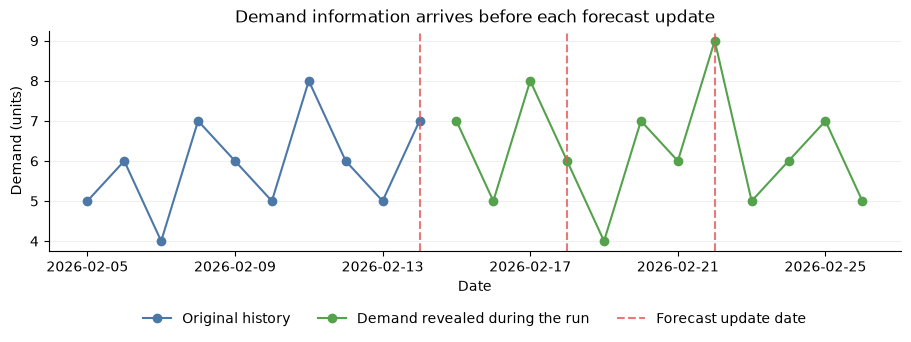

In [6]:
# Translate engine decision periods into the calendar dates shown on the plot.
update_dates = [opening_date + pd.Timedelta(days=p) for p in forecast_update_periods]

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(history['date'], history['y'], marker='o', color='#4C78A8', label='Original history')
ax.plot(
    simulation_demand['date'], simulation_demand['y'],
    marker='o', color='#54A24B', label='Demand revealed during the run',
)
# Vertical lines show the exact information cutoff for each external refit.
for index, update_date in enumerate(update_dates):
    ax.axvline(
        update_date, color='#E45756', linestyle='--', alpha=0.8,
        label='Forecast update date' if index == 0 else None,
    )
ax.set(title='Demand information arrives before each forecast update', xlabel='Date', ylabel='Demand (units)')
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=3)
fig.subplots_adjust(bottom=0.30)
plt.show()

## 2. Refit the external forecast at each rolling origin

Each `ES(model='ANN')` fit uses an expanding history ending at its forecast origin. At period 0 the model sees ten original observations. At periods 4 and 8 it sees those same ten rows plus the first four or eight newly observed demand rows. The model is deliberately unchanged so the example isolates the effect of new information.

We ask Smooth for two related outputs. The ordinary four-step forecast supplies daily means whose cumulative sum is useful for explaining the expected demand path. A separate `cumulative=True` call asks Smooth directly for the distribution of total four-day demand. Its final 95% upper bound becomes `S`. We do not add daily marginal upper bounds, because their sum is not generally a valid quantile of cumulative demand.

For every origin, the loop also creates a fresh fitted `OrderUpToPolicy`. A fitted snapshot packages the new target with its origin, horizon, probability, frequency, and end date. It contains no forecasting model and performs no refit when the engine later selects it.

In [7]:
# These caller-owned records keep the external forecast inputs and outputs inspectable.
availability_rows = []
forecast_path_frames = []
target_rows = []
# Each dictionary value will be one independently fitted policy snapshot.
policy_snapshots = {}

# Repeat the same external workflow at each chosen, valid review period.
for decision_period in forecast_update_periods:
    # The schedule key is a demand period; the origin is its preceding information date.
    forecast_origin = opening_date + pd.Timedelta(days=decision_period)

    # This is the information boundary: no demand after the origin enters the fit.
    # Include a simulated demand row only after its calendar date has arrived.
    newly_observed = simulation_demand.loc[
        simulation_demand['date'].le(forecast_origin),
        ['unique_id', 'date', 'y'],
    ]
    # The original history remains fixed; the later portion expands by origin.
    available_history = pd.concat([history, newly_observed], ignore_index=True)

    # Smooth is external to Stockcast. Fit the same simple model at every origin.
    model = ES(model='ANN')
    model.fit(available_history['y'])
    # Daily means are retained only to explain the expected cumulative path.
    daily_forecast = model.predict(
        h=protection_horizon,
        interval='prediction',
        level=service_level,
        side='upper',
        cumulative=False,
    )
    # This separate call directly models total demand over the full horizon.
    cumulative_forecast = model.predict(
        h=protection_horizon,
        interval='prediction',
        level=service_level,
        side='upper',
        cumulative=True,
    )

    # Forecast dates begin after the origin and cover exactly H forward days.
    forecast_dates = pd.date_range(
        forecast_origin + pd.Timedelta(days=1),
        periods=protection_horizon,
        freq=period_frequency,
    )
    # The final cumulative upper bound is the externally calculated target S.
    protection_target = float(cumulative_forecast.upper.iloc[-1, 0])
    target_end_date = forecast_dates[-1]

    # Record the input cutoff separately from the numerical forecast output.
    availability_rows.append({
        'decision_period': decision_period,
        'forecast_origin': forecast_origin,
        'observed_through': available_history['date'].max(),
        'original_history_rows': len(history),
        'new_demand_rows_available': len(newly_observed),
        'total_fit_rows': len(available_history),
    })
    # Accumulating means is valid for an expectation and creates a readable path.
    forecast_path_frames.append(pd.DataFrame({
        'decision_period': decision_period,
        'forecast_origin': forecast_origin,
        'date': forecast_dates,
        'cumulative_mean': daily_forecast.mean.to_numpy().cumsum(),
    }))
    # Keep all scientific meaning of the handoff beside the target value.
    target_rows.append({
        'unique_id': sku,
        'decision_period': decision_period,
        'protection_target': protection_target,
        'target_probability': service_level,
        'protection_horizon': protection_horizon,
        'forecast_origin': forecast_origin,
        'forecast_frequency': period_frequency,
        'target_end_date': target_end_date,
        'representation': 'cumulative_upper_prediction_interval',
        'target_source': 'external_direct',
    })

    # OrderUpToPolicy needs one direct cumulative target row for this SKU.
    target_for_fit = pd.DataFrame({
        'unique_id': [sku],
        'protection_target': [protection_target],
        'target_end_date': [target_end_date],
    })
    # Fit a new snapshot; do not mutate or refit a policy already used elsewhere.
    policy_snapshots[decision_period] = OrderUpToPolicy(
        lead_time=lead_time,
        review_period=review_period,
        service_level=service_level,
        allow_backorders=False,
    ).fit(
        target_for_fit,
        # These arguments validate what S represents and when it was knowable.
        target_column='protection_target',
        target_probability=service_level,
        protection_horizon=protection_horizon,
        target_source='external_direct',
        forecast_origin=forecast_origin,
        forecast_frequency=period_frequency,
        target_end_date_column='target_end_date',
    )

In [8]:
availability = pd.DataFrame(availability_rows)

# observed_through equals forecast_origin in every row: no fit sees later demand.
assert (availability['observed_through'] == availability['forecast_origin']).all()
assert availability['new_demand_rows_available'].tolist() == [0, 4, 8]

print('Information available at each rolling origin')
print(availability.to_string(index=False))


Information available at each rolling origin
 decision_period forecast_origin observed_through  original_history_rows  new_demand_rows_available  total_fit_rows
               0      2026-02-14       2026-02-14                     10                          0              10
               4      2026-02-18       2026-02-18                     10                          4              14
               8      2026-02-22       2026-02-22                     10                          8              18


In [9]:
forecast_paths = pd.concat(forecast_path_frames, ignore_index=True)

# Three origins times four horizon days give twelve cumulative-mean rows.
assert len(forecast_paths) == len(forecast_update_periods) * protection_horizon

print('Cumulative forecast paths')
print(forecast_paths.to_string(index=False, float_format=lambda value: f'{value:.3f}'))


Cumulative forecast paths
 decision_period forecast_origin       date  cumulative_mean
               0      2026-02-14 2026-02-15            5.900
               0      2026-02-14 2026-02-16           11.800
               0      2026-02-14 2026-02-17           17.700
               0      2026-02-14 2026-02-18           23.600
               4      2026-02-18 2026-02-19            6.071
               4      2026-02-18 2026-02-20           12.143
               4      2026-02-18 2026-02-21           18.214
               4      2026-02-18 2026-02-22           24.286
               8      2026-02-22 2026-02-23            6.167
               8      2026-02-22 2026-02-24           12.333
               8      2026-02-22 2026-02-25           18.500
               8      2026-02-22 2026-02-26           24.667


In [10]:
targets = pd.DataFrame(target_rows)

# One direct upper-bound target per rolling origin becomes one policy snapshot.
assert len(targets) == len(forecast_update_periods)

print('Forecast-to-target handoff')
print(targets.to_string(index=False, float_format=lambda value: f'{value:.3f}'))


Forecast-to-target handoff
unique_id  decision_period  protection_target  target_probability  protection_horizon forecast_origin forecast_frequency target_end_date                       representation   target_source
 tea_250g                0             27.777               0.950                   4      2026-02-14                  D      2026-02-18 cumulative_upper_prediction_interval external_direct
 tea_250g                4             28.417               0.950                   4      2026-02-18                  D      2026-02-22 cumulative_upper_prediction_interval external_direct
 tea_250g                8             29.355               0.950                   4      2026-02-22                  D      2026-02-26 cumulative_upper_prediction_interval external_direct


Read the three printed tables together. `observed_through` equals `forecast_origin` in every row, while `new_demand_rows_available` grows from 0 to 4 to 8. That is the evidence that the expanding fit never crosses its information boundary.

The cumulative-mean table explains the center of each four-day forecast. The handoff table is the stronger inventory input: it records the directly calculated cumulative upper bound and the metadata needed to interpret it. Later simulation demand exists in the complete scenario table, but no origin uses values dated after itself.

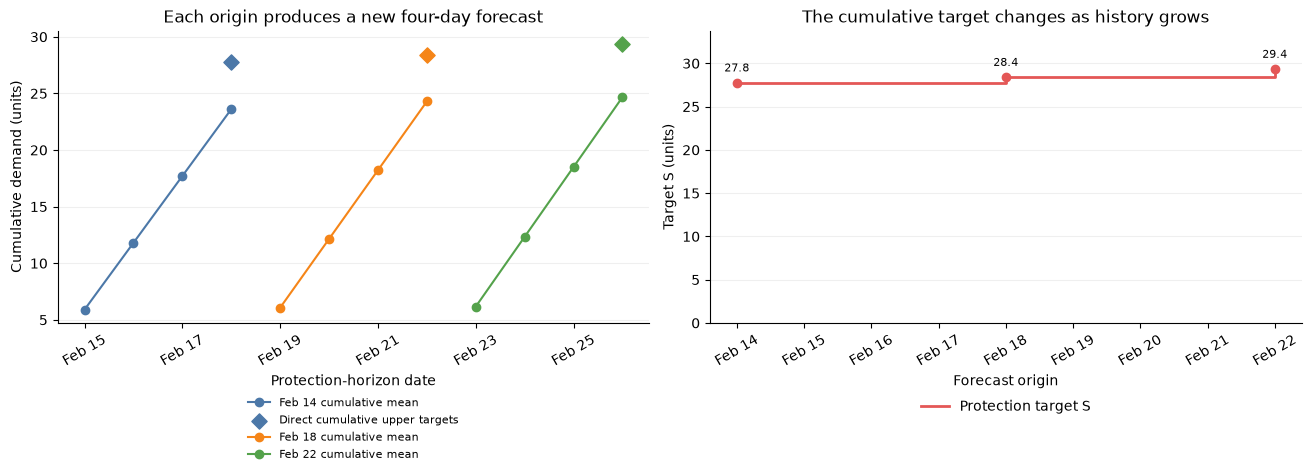

In [11]:
# Use one color per origin in both the cumulative paths and target markers.
colors = ['#4C78A8', '#F58518', '#54A24B']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), layout='constrained')

# The left panel compares what each successive information set produced.
for color, decision_period in zip(colors, forecast_update_periods):
    path = forecast_paths.loc[forecast_paths['decision_period'].eq(decision_period)]
    origin_label = path['forecast_origin'].iloc[0].strftime('%b %d')
    axes[0].plot(
        path['date'], path['cumulative_mean'], marker='o', color=color,
        label=f'{origin_label} cumulative mean',
    )
    # The diamond is the direct cumulative upper bound, not the final mean.
    direct_target = targets.loc[
        targets['decision_period'].eq(decision_period), 'protection_target',
    ].iloc[0]
    axes[0].scatter(
        path['date'].iloc[-1], direct_target, marker='D', s=60,
        color=color, zorder=3,
        label='Direct cumulative upper targets' if decision_period == 0 else None,
    )

axes[0].set(
    title='Each origin produces a new four-day forecast',
    xlabel='Protection-horizon date', ylabel='Cumulative demand (units)',
)
axes[0].legend(frameon=False, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.22))

# The right panel isolates the only policy input that changes between snapshots.
axes[1].step(
    targets['forecast_origin'], targets['protection_target'],
    where='post', color='#E45756', linewidth=2, label='Protection target S',
)
axes[1].scatter(targets['forecast_origin'], targets['protection_target'], color='#E45756', zorder=3)
for row in targets.itertuples(index=False):
    axes[1].annotate(
        f'{row.protection_target:.1f}',
        (row.forecast_origin, row.protection_target),
        xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8,
    )
axes[1].set(title='The cumulative target changes as history grows', xlabel='Forecast origin', ylabel='Target S (units)')
axes[1].set_ylim(0, targets['protection_target'].max() * 1.15)
axes[1].legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.22))

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()

## 3. Build the policy schedule

All three snapshots are the same `(R, S)` policy: same class, lead time, review period, service level, and lost-sales mode. This compatibility matters because `policy_schedule` is a target-update mechanism, not a way to switch policy behavior during a run. The engine rejects snapshots whose operating configuration differs from the base policy.

Demand period 0 uses the base policy for its pre-demand decision. The snapshot mapping contains later replacements keyed by zero-based demand period. When period 4 arrives, its snapshot becomes active and remains active at period 6; the period-8 snapshot then remains active through the rest of the run.

In [12]:
# The opening snapshot is passed through the ordinary policy argument.
base_policy = policy_snapshots[0]
# Only replacement snapshots belong in policy_schedule. Keys must be valid
# demand periods, and each snapshot origin must match its pre-demand information cutoff.
policy_schedule = {period: policy_snapshots[period] for period in [4, 8]}

# This caller-owned table makes the base-versus-update roles explicit.
schedule_table = targets[[
    'decision_period', 'forecast_origin', 'protection_target',
    'protection_horizon', 'target_end_date',
]].copy()
schedule_table.insert(1, 'engine_role', ['base policy', 'scheduled update', 'scheduled update'])
print(schedule_table.to_string(index=False, float_format=lambda value: f'{value:.3f}'))

 decision_period      engine_role forecast_origin  protection_target  protection_horizon target_end_date
               0      base policy      2026-02-14             27.777                   4      2026-02-18
               4 scheduled update      2026-02-18             28.417                   4      2026-02-22
               8 scheduled update      2026-02-22             29.355                   4      2026-02-26


## 4. Run the engine with the scheduled snapshots

Opening stock is an independently declared scenario input. It is not estimated from the history, forecast mean, or service level. We initialize twelve physical units on hand, no backorders, and an empty lead-time pipeline at the opening date.

The engine receives the complete demand calendar, the opening inventory, the base policy, and the two already fitted snapshots. It does not receive `ES`, a model object, or instructions to refit anything. Every scheduled decision occurs before its current demand, including the first one. All twelve demand periods are scored so this lesson stays focused on rolling updates rather than experiment-window design.

In [13]:
# Opening stock is a declared physical-state input, independent of the forecast.
opening_stock = pd.DataFrame({'unique_id': [sku], 'observed_on_hand': [12.0]})
opening_stock


,unique_id,observed_on_hand
0,tea_250g,12.0


In [14]:
# max_lead_time sizes the pipeline that will hold accepted two-day orders.
# The engine will deep-copy this state; the caller-owned object stays unchanged.
opening_inventory = InventoryStateDataFrame(
    [sku], max_lead_time=lead_time, allow_backorders=False,
).initialize_from_observed(
    opening_stock,
    on_hand_column='observed_on_hand',
    start_date=opening_date,
)
opening_inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=12, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [15]:
print('Opening inventory')
print(opening_inventory.inventory_position()[[
    'unique_id', 'date', 'period', 'on_hand', 'total_in_transit',
    'backorders', 'inventory_position',
]].to_string(index=False))


Opening inventory
unique_id       date  period  on_hand  total_in_transit  backorders  inventory_position
 tea_250g 2026-02-14     0.0     12.0               0.0         0.0                12.0


In [16]:
result = SimulationEngine().run(
    # The base snapshot supplies the opening target and remains active until period 4.
    policy=base_policy,
    # Scheduled snapshots replace only the fitted target at periods 4 and 8.
    policy_schedule=policy_schedule,
    # The engine validates and materializes this complete one-SKU daily calendar.
    demand_source=simulation_demand,
    # The engine deep-copies this state; the caller's opening object is preserved.
    inventory=opening_inventory,
    n_periods=len(simulation_demand),
    period_frequency=period_frequency,
    # Use the period-0 base target before the first demand row is processed.
    initial_decision='none',
    # Keep all twelve demand periods in one scoring window for this lesson.
    warmup_periods=0,
    scoring_periods=len(simulation_demand),
    settlement_periods=0,
    order_during_settlement=False,
    # Provenance names the declared deterministic input; no random generator is used.
    demand_source_name='declared_rolling_tea_demand',
    random_seed=None,
)

In [17]:
# The engine owns this state; the caller-owned `opening_inventory` above is unchanged.
result.inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=6, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

## 5. Confirm what the engine used

The result has two complementary evidence layers. The run manifest records the declared update periods and the dated metadata of each selected snapshot. That proves when the engine changed snapshots and which forecast origin and protection end date accompanied the change.

The canonical event ledger records what happened operationally. Its `target_level` column shows the numerical target active in each period, including intervening reviews where no new snapshot arrived. `order_quantity` is accepted into the lead-time pipeline at a decision; `received_units` records when that pipeline quantity later becomes physical stock.

In [18]:
# Keep the opening-decision event and all period events so timing is continuous.
events = result.to_event_frame(window='all')
# Select the flow and state fields needed to follow target-to-order consequences.
event_columns = [
    'event_type', 'period', 'date', 'is_review_period', 'demand',
    'target_level', 'order_quantity', 'received_units',
    'ending_on_hand', 'on_order_end', 'shortage_units',
]
print(f"Engine events: {len(events)} rows (twelve demand periods including the first scheduled decision)")
print('Canonical engine events')
print(events[event_columns].to_string(index=False, float_format=lambda value: f'{value:.3f}'))


Engine events: 12 rows (twelve demand periods including the first scheduled decision)
Canonical engine events
event_type  period       date  is_review_period  demand  target_level  order_quantity  received_units  ending_on_hand  on_order_end  shortage_units
    period   1.000 2026-02-15              True   7.000        27.777          15.777           0.000           5.000        15.777           0.000
    period   2.000 2026-02-16             False   5.000        27.777           0.000           0.000           0.000        15.777           0.000
    period   3.000 2026-02-17              True   8.000        27.777          12.000          15.777           7.777        12.000           0.000
    period   4.000 2026-02-18             False   6.000        27.777           0.000           0.000           1.777        12.000           0.000
    period   5.000 2026-02-19              True   4.000        28.417          14.640          12.000           9.777        14.640           0.000
  

In [19]:
# The manifest is provenance evidence; it records which schedule entries fired.
run_settings = result.run_manifest['run_settings']
# Flatten only the small policy-update portion for a readable tutorial table.
manifest_updates = pd.json_normalize(run_settings['policy_update_log']).rename(columns={
    'target_metadata.forecast_origin': 'forecast_origin',
    'target_metadata.protection_horizon': 'protection_horizon',
    'target_metadata.target_end_date': 'target_end_date',
})
manifest_columns = [
    'decision_period', 'policy_name', 'forecast_origin',
    'protection_horizon', 'target_end_date',
]
print('Manifest policy update periods')
print(run_settings['policy_update_periods'])
print('\nManifest policy update log')
print(manifest_updates[manifest_columns].to_string(index=False))


Manifest policy update periods
[4, 8]

Manifest policy update log
 decision_period       policy_name     forecast_origin  protection_horizon     target_end_date
               4 Order-Up-To (R,S) 2026-02-18T00:00:00                   4 2026-02-22T00:00:00
               8 Order-Up-To (R,S) 2026-02-22T00:00:00                   4 2026-02-26T00:00:00


In [20]:
# Event rows retain the numerical target, including reviews between updates.
decision_evidence = events.loc[
    events['decision_flag'],
    ['period', 'date', 'target_level', 'order_quantity', 'on_order_end'],
]
print('Numerical target evidence at engine decisions')
print(decision_evidence.to_string(index=False, float_format=lambda value: f'{value:.3f}'))


Numerical target evidence at engine decisions
 period       date  target_level  order_quantity  on_order_end
  1.000 2026-02-15        27.777          15.777        15.777
  3.000 2026-02-17        27.777          12.000        12.000
  5.000 2026-02-19        28.417          14.640        14.640
  7.000 2026-02-21        28.417          11.000        11.000
  9.000 2026-02-23        29.355          15.938        15.938
 11.000 2026-02-25        29.355          11.000        11.000


The manifest proves that updates were selected at periods 4 and 8 with forecast origins equal to those decision dates. The numerical event evidence then shows the persistence rule: the opening target is used at periods 0 and 2, the period-4 target is used at periods 4 and 6, and the period-8 target remains active at periods 8 and 10.

This division is deliberate. The current manifest retains update timing and target metadata, while the canonical events retain the numerical `target_level` that actually drove each decision. Together they connect the external rolling forecasts to the engine's operational record without claiming that the engine fitted those forecasts.

In [21]:
# InventoryEvaluator reads validated events rather than reconstructing state.
metrics = InventoryEvaluator().fit(
    # The window is explicit even though every demand period is scoring here.
    simulation_result=result, window='scoring',
).evaluate(
    # Keep the evidence compact: service, average stock, and ordered volume.
    metrics=[fill_rate, demand_period_service_level, avg_on_hand, order_units],
    # An empty grouping list produces one pooled result for this one-SKU run.
    groupby=[],
)
print('Scoring-window metrics')
print(metrics.round(3).to_string(index=False))

Scoring-window metrics
 fill_rate  demand_period_service_level  avg_on_hand  order_units
       1.0                          1.0        5.791       80.355


### Follow the updated targets through operations

The final figure reads from the same validated event rows used by the evaluator. The demand panel supplies context. The next two panels separate the active target and order decision from the later physical receipt, preventing the lead-time shift from being mistaken for immediate replenishment.

Orders are placed before demand at scheduled epochs and immediately enter `on_order_end`. Receipts arrive before current demand after the two-day lead time. The bottom panel therefore compares two end-of-day state quantities: physical on-hand stock and still-unreceived pipeline stock.

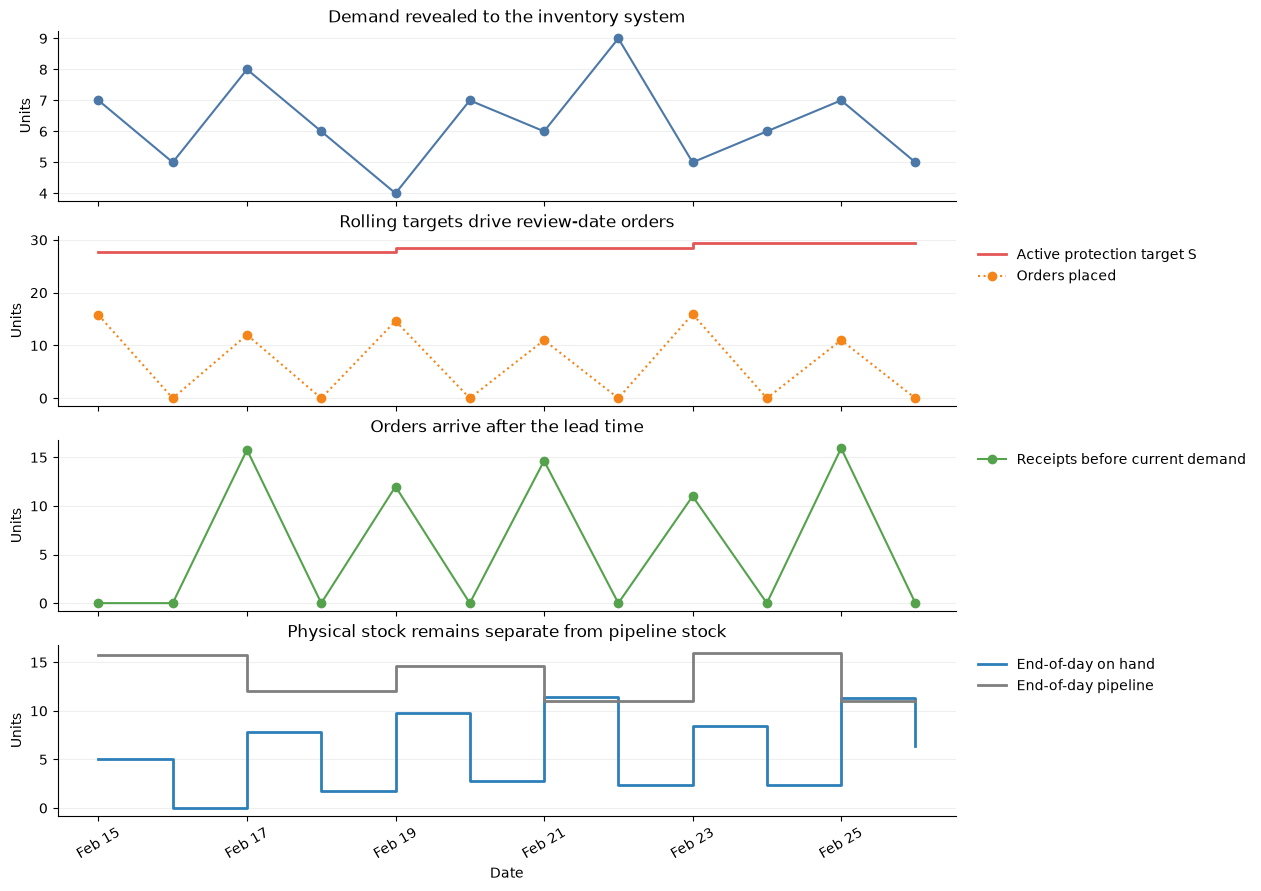

In [22]:
# Plot the twelve dated demand epochs, including the first decision.
period_events = events.loc[events['event_type'].eq('period')].copy()
fig, axes = plt.subplots(4, 1, figsize=(12.5, 8.8), sharex=True, layout='constrained')

# Panel 1: realized demand that advances both inventory and later forecast history.
axes[0].plot(period_events['date'], period_events['demand'], marker='o', color='#4C78A8')
axes[0].set(title='Demand revealed to the inventory system', ylabel='Units')

# Panel 2: the step line persists each snapshot target between update dates.
axes[1].step(
    period_events['date'], period_events['target_level'], where='post',
    color='#E45756', linewidth=2, label='Active protection target S',
)
axes[1].plot(
    period_events['date'], period_events['order_quantity'],
    marker='o', linestyle=':', color='#F58518', label='Orders placed',
)
axes[1].set(title='Rolling targets drive review-date orders', ylabel='Units')

# Panel 3: receipts are shown on their arrival dates, two days after orders.
axes[2].plot(
    period_events['date'], period_events['received_units'],
    marker='o', color='#54A24B', label='Receipts before current demand',
)
axes[2].set(title='Orders arrive after the lead time', ylabel='Units')

# Panel 4: both lines are end-of-day state, but only on-hand is physical stock.
axes[3].step(
    period_events['date'], period_events['ending_on_hand'], where='post',
    color='#2C7FB8', linewidth=2, label='End-of-day on hand',
)
axes[3].step(
    period_events['date'], period_events['on_order_end'], where='post',
    color='#7F7F7F', linewidth=2, label='End-of-day pipeline',
)
axes[3].set(title='Physical stock remains separate from pipeline stock', xlabel='Date', ylabel='Units')

for ax in axes:
    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
# Keep every legend outside the data area so no order or state is hidden.
axes[1].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
axes[2].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
axes[3].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[3].tick_params(axis='x', rotation=30)
plt.show()

## Takeaway

Rolling forecast integration is an outer-workflow responsibility. At each valid decision date, newly observed demand can be used to refit an external model, calculate a new cumulative protection target, and fit a compatible policy snapshot. The information cutoff belongs to that outer workflow and must be enforced before the snapshot reaches Stockcast.

`policy_schedule` then gives `SimulationEngine` a controlled way to select the dated snapshot at the matching decision period. The engine validates compatibility, applies the new target to ordinary `(R, S)` decisions, advances orders through the lead-time pipeline, and retains manifest and event evidence. It never trains or updates the forecasting model internally.

This is a mechanical, explicitly declared scenario. Stockcast accounts for inventory consequences; it does not infer missing business inputs or validate that the assumptions fit a real operation.